<a href="https://colab.research.google.com/github/Chexor/Epoch-Fail-Challenges/blob/main/Decision_Labyrinth_Epoch_Fail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introduction

## 1.1 Introduction

This notebook contains the full reproducible solution for **The Decision Labyrinth** challenge.

The workbook `Xy.xlsx` contains `10` sheets. Each sheet represents one layer of the labyrinth. For every layer we train decision trees with different `max_depth` values, inspect training/validation behaviour, and select the most stable depth.

The selected depths become the digits needed to solve the final puzzle.

## 1.2 Assignment

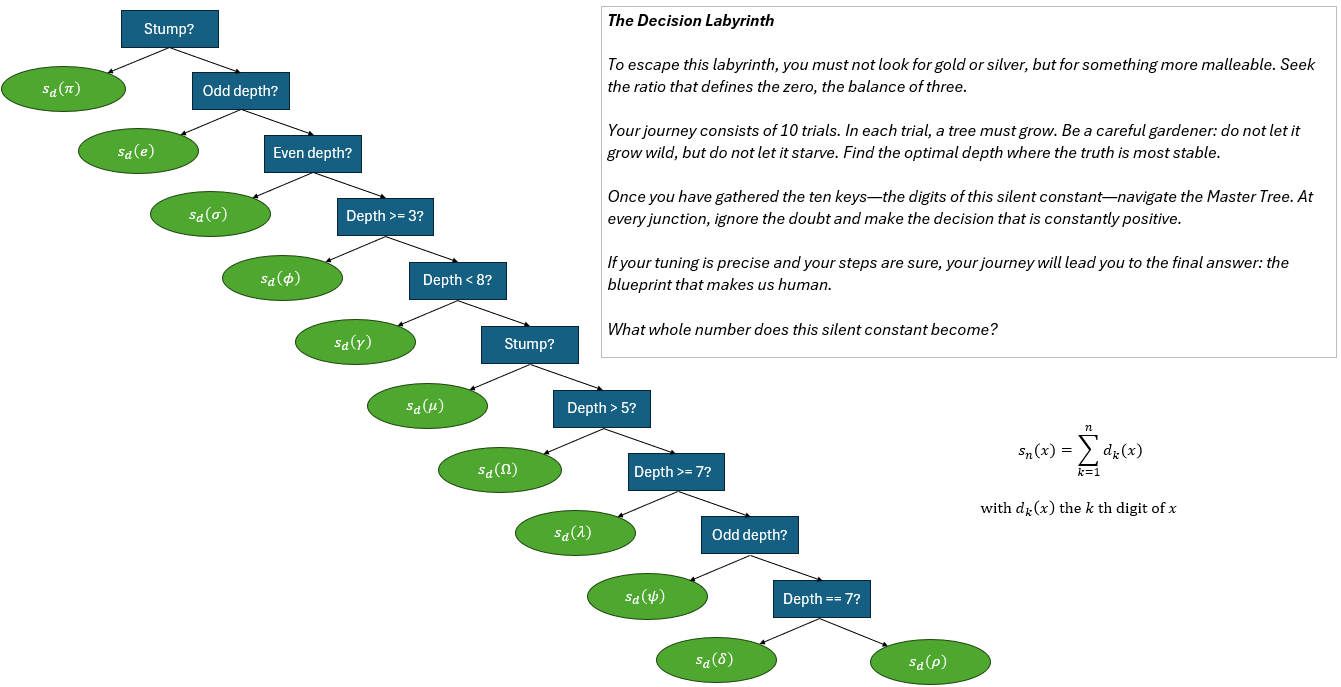


The assignment gives these instructions:

1. Complete `10` trials.
2. In each trial, grow a decision tree.
3. Do not let the tree grow too wild, but do not let it starve.
4. Find the optimal depth where the truth is most stable.
5. Use the resulting `10` digits to identify the hidden constant.
6. Apply the digit-sum formula:

$$
s_n(x) = \sum_{k=1}^{n} d_k(x)
$$

where $d_k(x)$ is the $k$-th digit of $x$.

## 1.3 Table of Contents

1. **Introduction**
   - 1.1 Introduction
   - 1.2 Assignment
   - 1.3 Table of Contents
2. **Setup**
   - 2.1 Import Libraries
   - 2.2 Import Data
   - 2.3 Shared Helpers
3. **Layer-by-Layer Solution**
   - 3.1 Layer 1
   - 3.2 Layer 2
   - 3.3 Layer 3
   - 3.4 Layer 4
   - 3.5 Layer 5
   - 3.6 Layer 6
   - 3.7 Layer 7
   - 3.8 Layer 8
   - 3.9 Layer 9
   - 3.10 Layer 10
   - 3.11 Reconstruct the Digits
4. **Conclusion**

# 2. Setup

## 2.1 Import Libraries

This cell imports the libraries used for workbook parsing, preprocessing, modelling and visualisation.

In [ ]:
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import openpyxl
except ImportError as exc:
    raise ImportError(
        "openpyxl is required to read Xy.xlsx. "
        "In Google Colab it is usually already installed. "
        "If it is missing, install it in a separate cell with: %pip install openpyxl"
    ) from exc

from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 2.2 Import Data

Upload `Xy.xlsx` when prompted. If it is already present in the notebook directory, it will be used directly.

In [ ]:
XLSX_PATH = Path("Xy.xlsx")

if not XLSX_PATH.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            XLSX_PATH = Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError("Upload Xy.xlsx or place it next to this notebook.") from exc

print("Using workbook:", XLSX_PATH)

Using workbook: Xy.xlsx


In [ ]:
raw_sheets = pd.read_excel(XLSX_PATH, sheet_name=None, header=None, engine="openpyxl")
print("Sheets:", list(raw_sheets.keys()))

for name, df in raw_sheets.items():
    non_empty_rows = df.dropna(how="all").shape[0]
    non_empty_cols = df.dropna(how="all", axis=1).shape[1]
    print(f"Sheet {name}: {non_empty_rows} rows x {non_empty_cols} non-empty columns")

Sheets: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Sheet 1: 101 rows x 1 non-empty columns
Sheet 2: 8 rows x 4 non-empty columns
Sheet 3: 0 rows x 0 non-empty columns
Sheet 4: 160 rows x 5 non-empty columns
Sheet 5: 5000 rows x 9 non-empty columns
Sheet 6: 201 rows x 3 non-empty columns
Sheet 7: 3000 rows x 9 non-empty columns
Sheet 8: 10001 rows x 11 non-empty columns
Sheet 9: 3201 rows x 6 non-empty columns
Sheet 10: 500 rows x 9 non-empty columns


## 2.3 Shared Helpers

### Validation strategy

For normal-sized sheets, the notebook uses **repeated stratified holdout validation**:

- `70%` train
- `30%` validation
- stratified by `y` when possible
- repeated over multiple random seeds

This is not full k-fold cross-validation. The goal is to detect a stable depth pattern for each puzzle layer, not to tune a production model.

### Depth selection rule

A selected depth is not automatically the deepest tree. We choose the depth where:

- validation accuracy reaches a clear jump or plateau
- deeper trees mostly improve train accuracy, not validation accuracy
- the chosen tree is the smallest stable tree that captures the pattern
- for puzzle-ambiguous layers, the choice also remains coherent with the final digit sequence

In [ ]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def clean_table(df):
    """Drop fully empty rows/columns and reset indexes."""
    return df.dropna(how="all").dropna(how="all", axis=1).reset_index(drop=True)


def standard_xy(df, *, header=False, feature_names=None, target_name="y"):
    """Build a clean X/y table from a sheet where the last column is the target."""
    df = clean_table(df).copy()

    if header:
        columns = [str(x) for x in df.iloc[0].tolist()]
        df = df.iloc[1:].reset_index(drop=True)
        df.columns = columns
    else:
        if feature_names is None:
            feature_names = [f"x{i}" for i in range(df.shape[1] - 1)]
        df.columns = list(feature_names) + [target_name]

    X = df.iloc[:, :-1].replace(-9999, np.nan)
    y = df.iloc[:, -1]
    return X, y


def infer_columns(X):
    numeric_cols = []
    categorical_cols = []

    for col in X.columns:
        converted = pd.to_numeric(X[col], errors="coerce")
        non_missing_original = X[col].notna().sum()
        non_missing_numeric = converted.notna().sum()

        if non_missing_original == non_missing_numeric:
            X[col] = converted
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)

    return numeric_cols, categorical_cols


def depth_scan(X, y, *, depths=range(1, 13), seeds=range(5), stratify=True):
    X = X.copy()
    y = pd.Series(y).astype(str)

    numeric_cols, categorical_cols = infer_columns(X)

    transformers = []
    if numeric_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), numeric_cols))
    if categorical_cols:
        transformers.append((
            "cat",
            make_pipeline(SimpleImputer(strategy="most_frequent"), make_one_hot_encoder()),
            categorical_cols,
        ))

    preprocess = ColumnTransformer(transformers)
    rows = []

    for depth in depths:
        train_scores = []
        validation_scores = []
        actual_depths = []

        for seed in seeds:
            can_stratify = stratify and y.value_counts().min() >= 2 and len(y) >= 20

            if len(y) < 20:
                X_train, X_val, y_train, y_val = X, X, y, y
            else:
                X_train, X_val, y_train, y_val = train_test_split(
                    X,
                    y,
                    test_size=0.30,
                    random_state=seed,
                    stratify=y if can_stratify else None,
                )

            tree = DecisionTreeClassifier(max_depth=depth, random_state=seed)
            model = make_pipeline(preprocess, tree)
            model.fit(X_train, y_train)

            train_scores.append(accuracy_score(y_train, model.predict(X_train)))
            validation_scores.append(accuracy_score(y_val, model.predict(X_val)))
            actual_depths.append(model.named_steps["decisiontreeclassifier"].get_depth())

        rows.append({
            "max_depth": depth,
            "actual_depth_max": max(actual_depths),
            "train_mean": float(np.mean(train_scores)),
            "validation_mean": float(np.mean(validation_scores)),
            "validation_std": float(np.std(validation_scores)),
        })

    return pd.DataFrame(rows)


def show_scores(scores):
    display(scores.style.format({
        "train_mean": "{:.3f}",
        "validation_mean": "{:.3f}",
        "validation_std": "{:.3f}",
    }))


def plot_depth_scan(scores, selected_depth, title):
    """Plot train/validation behaviour and mark the selected max_depth."""
    x = scores["max_depth"]
    val = scores["validation_mean"]
    std = scores["validation_std"]

    plt.figure(figsize=(8, 4))
    plt.plot(x, scores["train_mean"], marker="o", label="Train accuracy")
    plt.plot(x, val, marker="o", label="Validation accuracy")
    plt.fill_between(x, val - std, val + std, alpha=0.15, label="Validation ±1 std")
    plt.axvline(selected_depth, color="red", linestyle="--", label=f"Selected depth = {selected_depth}")
    plt.title(title)
    plt.xlabel("max_depth")
    plt.ylabel("accuracy")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def selected_depth_row(scores, selected_depth):
    row = scores.loc[scores["max_depth"] == selected_depth]
    display(row.style.format({
        "train_mean": "{:.3f}",
        "validation_mean": "{:.3f}",
        "validation_std": "{:.3f}",
    }))


def show_class_balance(y, title):
    counts = pd.Series(y).astype(str).value_counts().sort_index()
    display(counts.rename("count").to_frame())
    counts.plot(kind="bar", figsize=(6, 3), title=title)
    plt.xlabel("class")
    plt.ylabel("count")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# 3. Layer-by-Layer Solution

## 3.1 Layer 1

### Data clean-up

Sheet `1` stores CSV text in one Excel column. We split it into `temperature` and `heating`.

,temperature,heating
0,19.5,off
1,21.2,off
2,20.0,off
3,19.4,off
4,18.2,on


,count
heating,
off,50
on,50


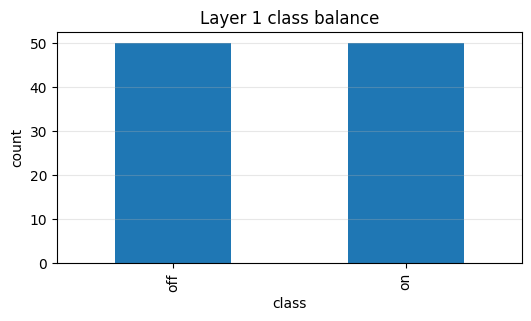

In [ ]:
sheet_1_raw = clean_table(raw_sheets["1"])
sheet_1 = sheet_1_raw.iloc[:, 0].astype(str).str.split(",", expand=True)
sheet_1.columns = sheet_1.iloc[0]
sheet_1 = sheet_1.iloc[1:].reset_index(drop=True)

sheet_1["temperature"] = sheet_1["temperature"].astype(float)

X1 = sheet_1[["temperature"]]
y1 = sheet_1["heating"]

display(sheet_1.head())
show_class_balance(y1, "Layer 1 class balance")

### Depth Scan

We scan shallow depths. The key question is whether one temperature threshold already separates the target.

In [ ]:
scores_1 = depth_scan(X1, y1, depths=range(1, 6))
show_scores(scores_1)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.994,0.967,0.037
1,2,2,1.000,0.967,0.037
2,3,2,1.000,0.967,0.037
3,4,2,1.000,0.967,0.037
4,5,2,1.000,0.967,0.037


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

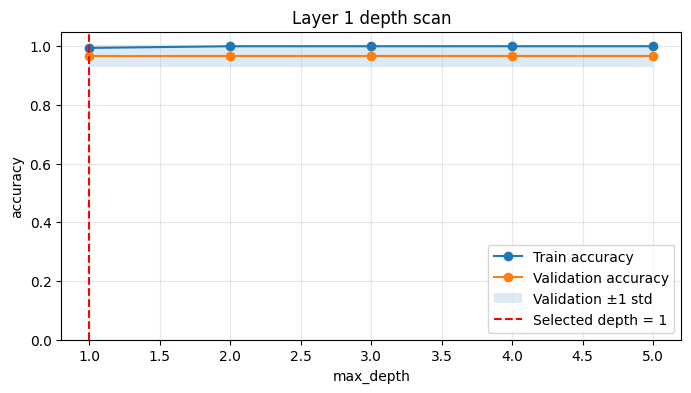

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.994,0.967,0.037


In [ ]:
d_1 = 1
plot_depth_scan(scores_1, d_1, "Layer 1 depth scan")
selected_depth_row(scores_1, d_1)

### Conclusion

Depth `1` is selected because one threshold split is already stable. Deeper trees add complexity without meaningful validation gain.

Selected depth:

$$
d_1 = 1
$$

## 3.2 Layer 2

### Data clean-up

Sheet `2` is a full truth table. We name the three binary inputs `x0`, `x1`, `x2` and use the last column as `y`.

,x0,x1,x2,y
0,0,0,1,1
1,1,0,1,0
2,0,0,0,0
3,1,1,1,1
4,0,1,0,1
5,1,0,0,1
6,0,1,1,0
7,1,1,0,0


,count
y,
0,4
1,4


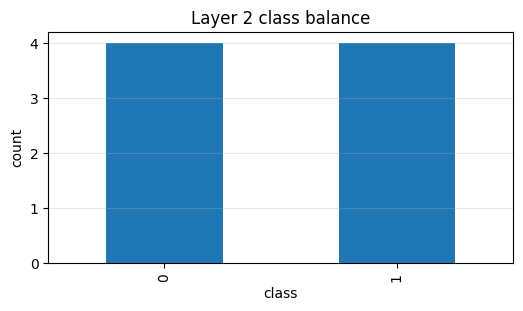

In [ ]:
sheet_2 = clean_table(raw_sheets["2"])
X2, y2 = standard_xy(sheet_2, feature_names=["x0", "x1", "x2"])

display(pd.concat([X2, y2.rename("y")], axis=1))
show_class_balance(y2, "Layer 2 class balance")

### Depth Scan

We scan depths `1` to `4`. Because this is only an 8-row truth table, structural fit matters more than random validation.

In [ ]:
scores_2 = depth_scan(X2, y2, depths=range(1, 5), seeds=range(1), stratify=False)
show_scores(scores_2)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.500,0.500,0.000
1,2,2,0.500,0.500,0.000
2,3,3,1.000,1.000,0.000
3,4,3,1.000,1.000,0.000


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

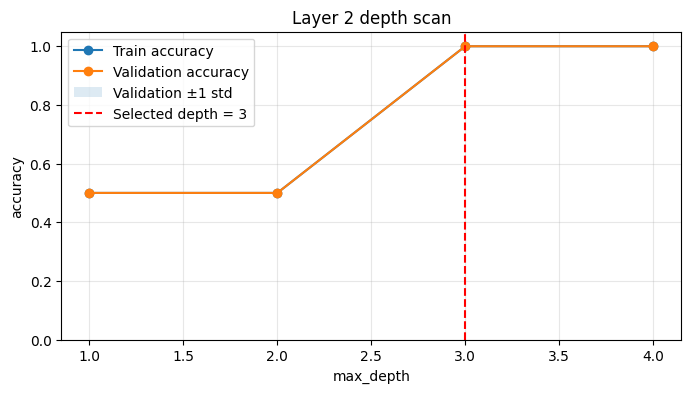

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
2,3,3,1.000,1.000,0.000


In [ ]:
d_2 = 3
plot_depth_scan(scores_2, d_2, "Layer 2 depth scan")
selected_depth_row(scores_2, d_2)

### Conclusion

Depth `3` is selected because the pattern behaves like parity/XOR over three features. A tree needs three decision layers to represent it.

Selected depth:

$$
d_2 = 3
$$

## 3.3 Layer 3

### Data clean-up

Sheet `3` is a visual layer: it has no usable tabular cell data, but it does contain an embedded image.

For this layer we manually annotate the `8` visible drinks from the image. This keeps the observed label count intact:

```text
happy = 5
sad   = 3
```

We keep the feature set intentionally simple:

- `has_stem`: `yes` or `no`
- `color`: `dark` or `light`
- `fruit`: `yes` or `no`
- `skewer`: `yes` or `no`

The target is:

- `label`: `happy` or `sad`

The stars are excluded because they behave like an output/symptom of being sad/drunk, not as an input feature. Including them would leak the target.

Embedded images: ['image1.png']


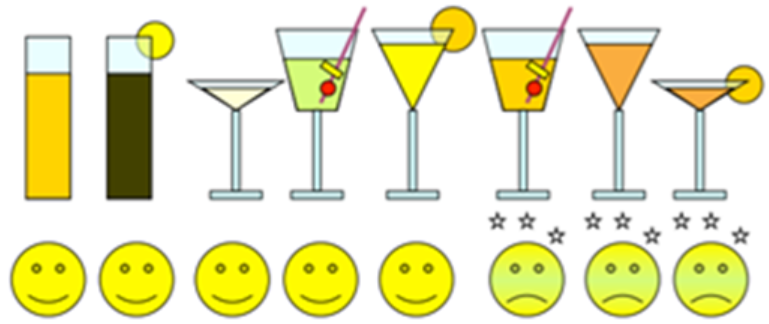

,drink,has_stem,color,fruit,skewer,label
0,1,no,light,no,no,happy
1,2,no,dark,yes,no,happy
2,3,yes,light,no,no,happy
3,4,yes,light,yes,yes,happy
4,5,yes,light,yes,no,happy
5,6,yes,dark,yes,yes,sad
6,7,yes,dark,no,no,sad
7,8,yes,dark,yes,no,sad


,has_stem_no,has_stem_yes,color_dark,color_light,fruit_no,fruit_yes,skewer_no,skewer_yes
0,1,0,0,1,1,0,1,0
1,1,0,1,0,0,1,1,0
2,0,1,0,1,1,0,1,0
3,0,1,0,1,0,1,0,1
4,0,1,0,1,0,1,1,0
5,0,1,1,0,0,1,0,1
6,0,1,1,0,1,0,1,0
7,0,1,1,0,0,1,1,0


,count
label,
happy,5
sad,3


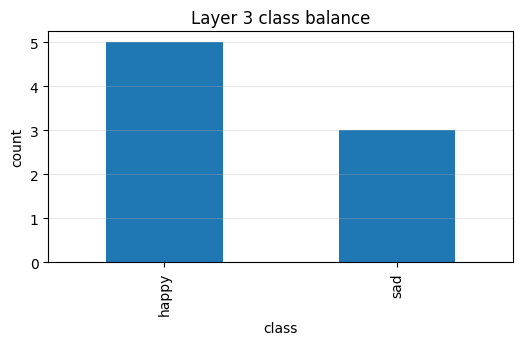

In [ ]:
embedded_images = []
with ZipFile(XLSX_PATH) as zf:
    for name in zf.namelist():
        if name.startswith("xl/media/") and name.lower().endswith((".png", ".jpg", ".jpeg")):
            output_path = Path(name).name
            Path(output_path).write_bytes(zf.read(name))
            embedded_images.append(output_path)

print("Embedded images:", embedded_images)
if embedded_images:
    display(Image(filename=embedded_images[0]))

layer_3 = pd.DataFrame([
    {"drink": 1, "has_stem": "no", "color": "light", "fruit": "no", "skewer": "no", "label": "happy"},
    {"drink": 2, "has_stem": "no", "color": "dark", "fruit": "yes", "skewer": "no", "label": "happy"},
    {"drink": 3, "has_stem": "yes", "color": "light", "fruit": "no", "skewer": "no", "label": "happy"},
    {"drink": 4, "has_stem": "yes", "color": "light", "fruit": "yes", "skewer": "yes", "label": "happy"},
    {"drink": 5, "has_stem": "yes", "color": "light", "fruit": "yes", "skewer": "no", "label": "happy"},
    {"drink": 6, "has_stem": "yes", "color": "dark", "fruit": "yes", "skewer": "yes", "label": "sad"},
    {"drink": 7, "has_stem": "yes", "color": "dark", "fruit": "no", "skewer": "no", "label": "sad"},
    {"drink": 8, "has_stem": "yes", "color": "dark", "fruit": "yes", "skewer": "no", "label": "sad"},
])

feature_cols_3 = ["has_stem", "color", "fruit", "skewer"]
X3 = layer_3[feature_cols_3]
y3 = layer_3["label"]

# One-hot encode the yes/no and dark/light features for the explicit tree visualisation.
X3_model = pd.get_dummies(X3, drop_first=False, dtype=int)

display(layer_3)
display(X3_model)
show_class_balance(y3, "Layer 3 class balance")

### Depth Scan

This layer is structurally different from the normal sheets. The dataset is a manually extracted visual annotation table, not a large statistical dataset.

The important question is whether one decision is enough. With this feature set, one feature is not enough:

- `color = dark` alone is not enough, because one dark drink is still `happy`.
- `has_stem = yes` alone is not enough, because several stemmed glasses are still `happy`.

A depth-2 tree can combine two visual conditions.

In [ ]:
scores_3 = depth_scan(X3_model, y3, depths=range(1, 5), seeds=range(1), stratify=False)
show_scores(scores_3)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.875,0.875,0.000
1,2,2,1.000,1.000,0.000
2,3,2,1.000,1.000,0.000
3,4,2,1.000,1.000,0.000


### Validation

For Layer `3`, validation is structural rather than statistical.

The plot compares train and validation accuracy for the manually annotated visual dataset. The tree plot shows which features are actually used from the simplified feature set.

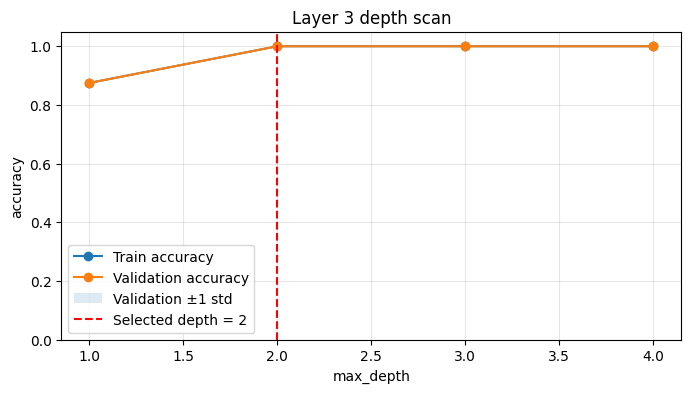

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
1,2,2,1.000,1.000,0.000


Features used by the tree: ['has_stem_no', 'color_light']


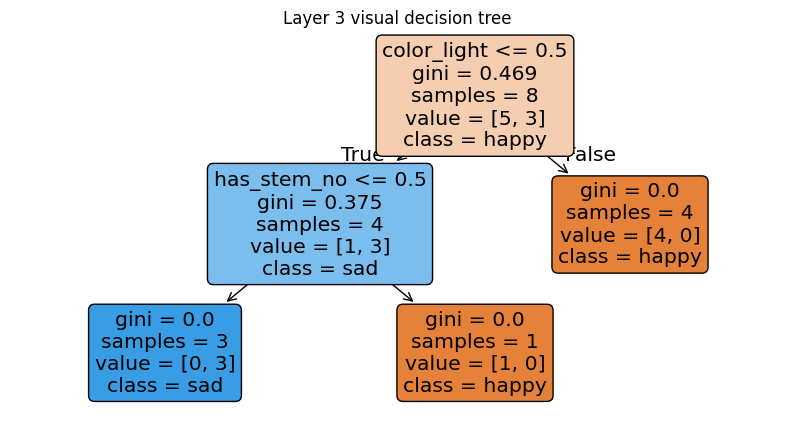

In [ ]:
d_3 = 2
plot_depth_scan(scores_3, d_3, "Layer 3 depth scan")
selected_depth_row(scores_3, d_3)

layer_3_tree = DecisionTreeClassifier(max_depth=d_3, random_state=0)
layer_3_tree.fit(X3_model, y3)

used_feature_ids = sorted(set(layer_3_tree.tree_.feature[layer_3_tree.tree_.feature >= 0]))
used_features = [X3_model.columns[i] for i in used_feature_ids]
print("Features used by the tree:", used_features)

plt.figure(figsize=(10, 5))
plot_tree(
    layer_3_tree,
    feature_names=list(X3_model.columns),
    class_names=sorted(y3.unique()),
    filled=True,
    rounded=True,
)
plt.title("Layer 3 visual decision tree")
plt.show()

### Conclusion

Depth `2` is selected with the simplified visual feature set.

A depth-1 tree can only ask one question, which is not enough here. For example, `color = dark` alone would incorrectly group one `happy` drink with the `sad` drinks. A depth-2 tree can combine visual conditions and correctly separate the annotated examples.

Features such as `fruit` and `skewer` are included, but the tree can ignore them if they do not improve the split.

Selected depth:

$$
d_3 = 2
$$

## 3.4 Layer 4

### Data clean-up

Sheet `4` contains four categorical symbol features and a smile/frown target. The symbols are handled by one-hot encoding in the pipeline.

,symbol_1,symbol_2,symbol_3,symbol_4,label
0,0))0,[}]}[},7&&7,./?/./,:)
1,0))0,[}]}[},./?/./,6^^6,:)
2,0))0,[}]}[},7&&7,6^^6,:(
3,./?/./,3##3,7&&7,6^^6,:(
4,0))0,3##3,./?/./,6^^6,:(


,count
label,
:(,80
:),80


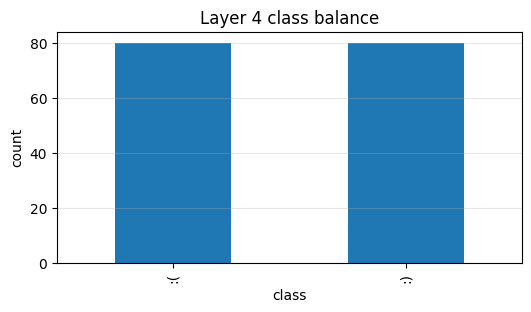

In [ ]:
sheet_4 = clean_table(raw_sheets["4"])
X4, y4 = standard_xy(sheet_4, feature_names=["symbol_1", "symbol_2", "symbol_3", "symbol_4"], target_name="label")

display(pd.concat([X4, y4.rename("label")], axis=1).head())
show_class_balance(y4, "Layer 4 class balance")

### Depth Scan

We scan depths `1` to `7` and look for the first clear validation jump/plateau.

In [ ]:
scores_4 = depth_scan(X4, y4, depths=range(1, 8))
show_scores(scores_4)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.546,0.475,0.031
1,2,2,0.561,0.433,0.052
2,3,3,0.584,0.387,0.034
3,4,4,0.966,0.954,0.016
4,5,4,0.966,0.954,0.016
5,6,4,0.966,0.954,0.016
6,7,4,0.966,0.954,0.016


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

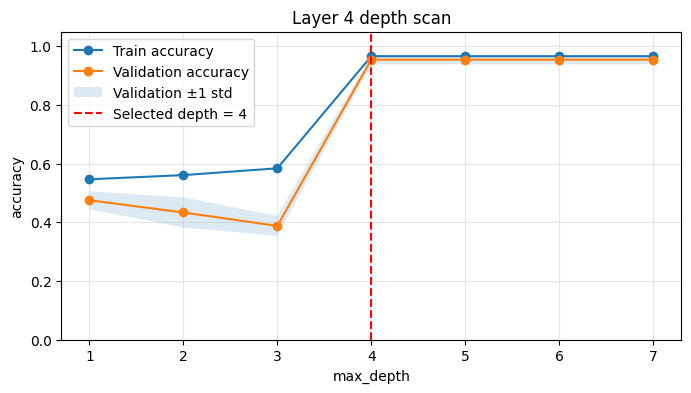

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
3,4,4,0.966,0.954,0.016


In [ ]:
d_4 = 4
plot_depth_scan(scores_4, d_4, "Layer 4 depth scan")
selected_depth_row(scores_4, d_4)

### Conclusion

Depth `4` is selected because validation performance jumps at this depth and deeper trees do not add stable value.

Selected depth:

$$
d_4 = 4
$$

## 3.5 Layer 5

### Data clean-up

Sheet `5` contains `5000` rows, `8` numeric features and `8` balanced target classes.

,x0,x1,x2,x3,x4,x5,x6,x7,y
0,0.464847,0.519938,0.398937,0.274181,0.081439,0.015071,0.002763,0.804178,3
1,0.253133,0.287656,0.769772,0.340227,0.872136,0.242575,0.028548,0.149661,1
2,0.098960,0.649964,0.147700,0.144862,0.472183,0.029659,0.225290,0.072277,0
3,0.267110,0.661969,0.814940,0.163034,0.243440,0.092059,0.129232,0.047385,0
4,0.335865,0.368742,0.095417,0.586513,0.400257,0.050754,0.046654,0.943859,4


,count
y,
0,625
1,625
2,625
3,625
4,625
5,625
6,625
7,625


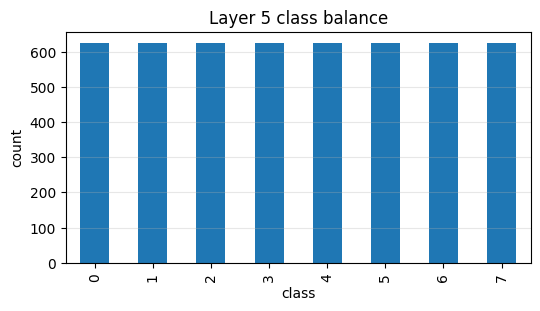

In [ ]:
sheet_5 = clean_table(raw_sheets["5"])
X5, y5 = standard_xy(sheet_5, feature_names=[f"x{i}" for i in range(8)])

display(pd.concat([X5, y5.rename("y")], axis=1).head())
show_class_balance(y5, "Layer 5 class balance")

### Depth Scan

We scan depths `1` to `12`. This layer has a gradual validation increase, so we also check where extra depth starts mainly helping training accuracy.

In [ ]:
scores_5 = depth_scan(X5, y5, depths=range(1, 13))
show_scores(scores_5)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.238,0.234,0.001
1,2,2,0.336,0.330,0.004
2,3,3,0.429,0.415,0.007
3,4,4,0.512,0.481,0.010
4,5,5,0.593,0.536,0.013
5,6,6,0.672,0.591,0.012
6,7,7,0.754,0.636,0.014
7,8,8,0.799,0.637,0.009
8,9,9,0.845,0.641,0.011
9,10,10,0.891,0.637,0.008


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

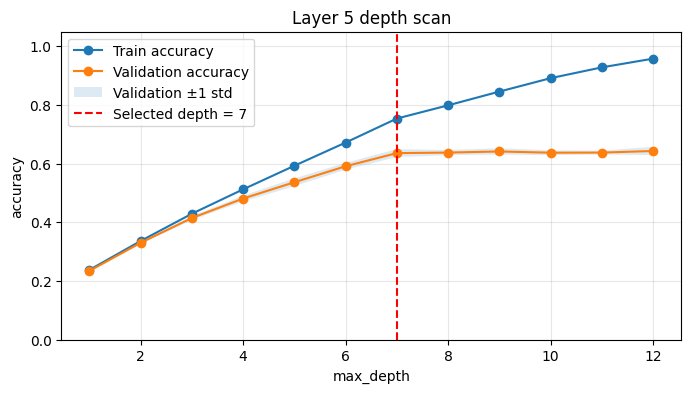

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
6,7,7,0.754,0.636,0.014


In [ ]:
d_5 = 7
plot_depth_scan(scores_5, d_5, "Layer 5 depth scan")
selected_depth_row(scores_5, d_5)

### Conclusion

Depth `7` is selected as the stable puzzle-coherent depth. Depth `9` can be slightly higher in pure validation, but it is more complex and less coherent with the reconstructed constant.

Selected depth:

$$
d_5 = 7
$$

## 3.6 Layer 6

### Data clean-up

Sheet `6` contains an index column, one categorical feature and a binary target. We remove the index and keep only `x` and `y`.

,x,y
0,A,False
1,A,False
2,B,True
3,B,True
4,B,False


,count
y,
False,100
True,100


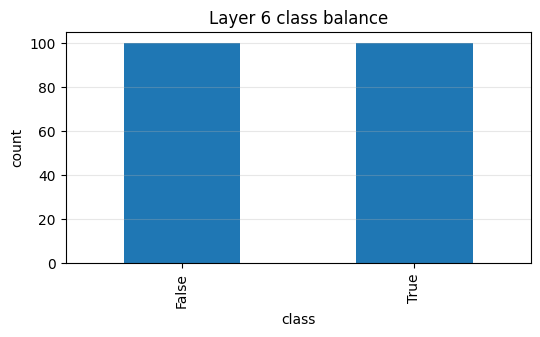

In [ ]:
sheet_6 = clean_table(raw_sheets["6"])
sheet_6 = sheet_6.iloc[1:].reset_index(drop=True)
sheet_6 = sheet_6.iloc[:, [1, 2]].copy()
sheet_6.columns = ["x", "y"]

X6 = sheet_6[["x"]]
y6 = sheet_6["y"]

display(sheet_6.head())
show_class_balance(y6, "Layer 6 class balance")

### Depth Scan

We scan depths `1` to `9`. If deeper trees improve training but not validation, that is overfitting.

In [ ]:
scores_6 = depth_scan(X6, y6, depths=range(1, 10))
show_scores(scores_6)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.950,0.917,0.011
1,2,1,0.950,0.917,0.011
2,3,1,0.950,0.917,0.011
3,4,1,0.950,0.917,0.011
4,5,1,0.950,0.917,0.011
5,6,1,0.950,0.917,0.011
6,7,1,0.950,0.917,0.011
7,8,1,0.950,0.917,0.011
8,9,1,0.950,0.917,0.011


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

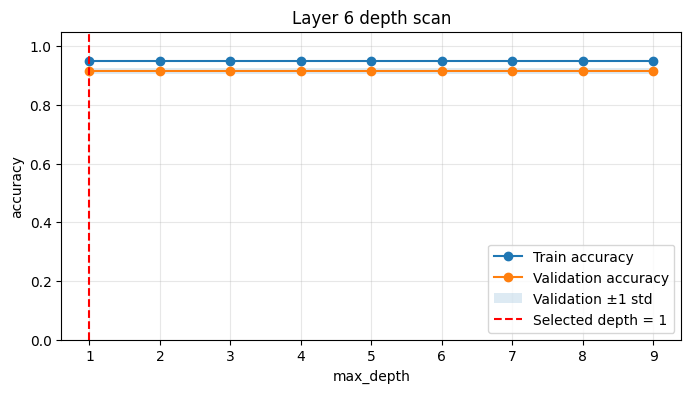

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.950,0.917,0.011


In [ ]:
d_6 = 1
plot_depth_scan(scores_6, d_6, "Layer 6 depth scan")
selected_depth_row(scores_6, d_6)

### Conclusion

Depth `1` is selected because one categorical split gives the most stable validation behaviour. Deeper trees mostly model noise.

Selected depth:

$$
d_6 = 1
$$

## 3.7 Layer 7

### Data clean-up

Sheet `7` contains `3000` rows, `8` numeric features, missing values and `8` balanced classes. Missing numeric values are median-imputed by the pipeline.

Missing values per feature:


,missing_count
x0,37
x1,20
x2,32
x3,24
x4,34
x5,31
x6,32
x7,30


,x0,x1,x2,x3,x4,x5,x6,x7,y
0,150.908338,NaN,236.870559,192.433351,15.018907,241.893089,306.226910,54.037596,0
1,345.391528,178.640469,33.940278,102.876334,602.101830,947.087547,488.838592,417.388010,3
2,366.973336,637.390850,68.000415,44.554691,535.554948,441.324329,74.290374,541.922305,4
3,198.197127,591.912015,94.553067,224.651016,294.335628,303.504232,406.988005,20.217520,3
4,569.828023,350.405917,241.542813,121.553241,537.534266,297.282675,224.475089,653.063196,4


,count
y,
0,375
1,375
2,375
3,375
4,375
5,375
6,375
7,375


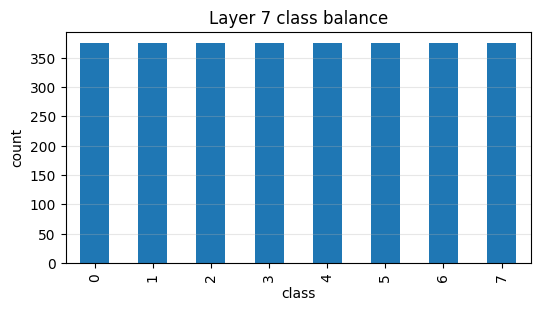

In [ ]:
sheet_7 = clean_table(raw_sheets["7"])
X7, y7 = standard_xy(sheet_7, feature_names=[f"x{i}" for i in range(8)])

print("Missing values per feature:")
display(X7.isna().sum().to_frame("missing_count"))
display(pd.concat([X7, y7.rename("y")], axis=1).head())
show_class_balance(y7, "Layer 7 class balance")

### Depth Scan

We scan depths `1` to `12` and look for the point where validation stops improving strongly while training keeps rising.

In [ ]:
scores_7 = depth_scan(X7, y7, depths=range(1, 13))
show_scores(scores_7)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.239,0.232,0.004
1,2,2,0.342,0.328,0.006
2,3,3,0.436,0.419,0.016
3,4,4,0.527,0.476,0.011
4,5,5,0.612,0.537,0.014
5,6,6,0.698,0.589,0.014
6,7,7,0.782,0.640,0.012
7,8,8,0.832,0.642,0.017
8,9,9,0.887,0.640,0.017
9,10,10,0.933,0.641,0.019


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

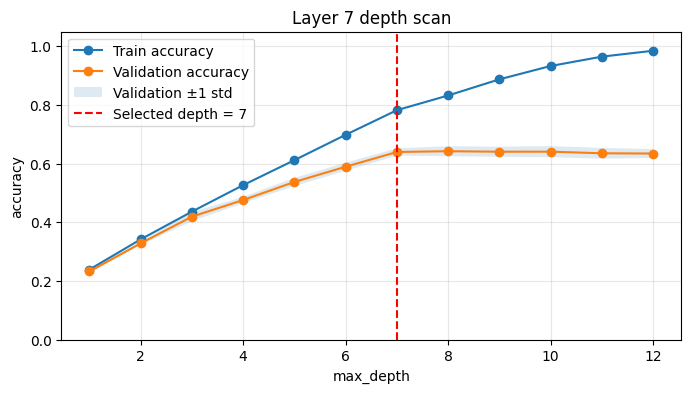

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
6,7,7,0.782,0.640,0.012


In [ ]:
d_7 = 7
plot_depth_scan(scores_7, d_7, "Layer 7 depth scan")
selected_depth_row(scores_7, d_7)

### Conclusion

Depth `7` is selected because it captures the multiclass pattern while avoiding the stronger overfitting visible at deeper depths.

Selected depth:

$$
d_7 = 7
$$

## 3.8 Layer 8

### Data clean-up

Sheet `8` contains `10000` rows, `10` numeric features and `10` balanced classes. The first row is a partial header, so we remove it and assign explicit names.

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,y
0,2.950156,0.435722,7.289526,1.097650,16.136883,0.976210,3.965012,14.624072,11.488389,2.705945,5
1,2.95437,7.027147,11.461199,0.147432,1.013336,1.862727,6.231896,15.516326,5.828492,6.634803,3
2,0.551851,1.070243,8.499236,3.855577,19.474757,1.975910,7.237609,15.772870,7.345974,13.985065,9
3,2.256667,4.935268,9.483894,11.711553,6.213604,1.248924,6.926379,17.459381,8.021955,14.356580,8
4,1.304354,2.158726,2.355237,15.572609,5.962576,1.753688,8.077912,4.204771,2.624380,5.106502,7


,count
y,
0,1000
1,1000
2,1000
3,1000
4,1000
5,1000
6,1000
7,1000
8,1000


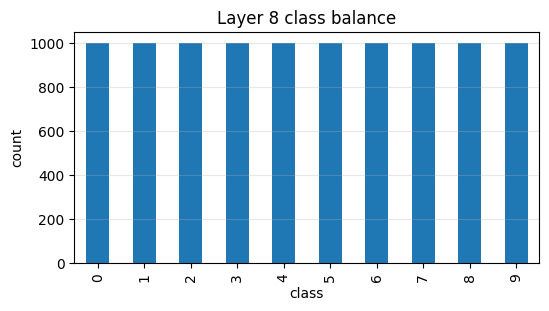

In [ ]:
sheet_8 = clean_table(raw_sheets["8"])
sheet_8 = sheet_8.iloc[1:].reset_index(drop=True)
sheet_8.columns = [f"x{i}" for i in range(10)] + ["y"]

X8 = sheet_8[[f"x{i}" for i in range(10)]]
y8 = sheet_8["y"]

display(sheet_8.head())
show_class_balance(y8, "Layer 8 class balance")

### Depth Scan

We scan a wider range because this is the largest dataset. The selected depth should be where validation peaks before overfitting.

In [ ]:
scores_8 = depth_scan(X8, y8, depths=range(1, 15))
show_scores(scores_8)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.192,0.191,0.002
1,2,2,0.277,0.273,0.003
2,3,3,0.356,0.347,0.002
3,4,4,0.430,0.411,0.002
4,5,5,0.498,0.472,0.003
5,6,6,0.567,0.523,0.005
6,7,7,0.637,0.568,0.009
7,8,8,0.707,0.613,0.007
8,9,9,0.780,0.649,0.009
9,10,10,0.818,0.648,0.011


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

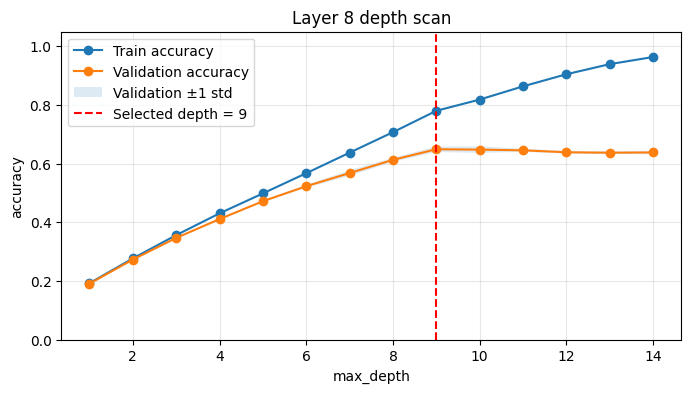

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
8,9,9,0.780,0.649,0.009


In [ ]:
d_8 = 9
plot_depth_scan(scores_8, d_8, "Layer 8 depth scan")
selected_depth_row(scores_8, d_8)

### Conclusion

Depth `9` is selected because validation performance peaks around this point; deeper trees mainly increase training accuracy.

Selected depth:

$$
d_8 = 9
$$

## 3.9 Layer 9

### Data clean-up

Sheet `9` contains five binary-style features with values `0` and `5`. The first row contains headers.

,X0,X1,X2,X3,X4,y
0,0,5,0,0,0,1
1,0,0,0,5,5,1
2,0,0,0,0,0,0
3,5,0,0,0,0,1
4,0,5,5,0,5,1


,count
y,
0,1600
1,1600


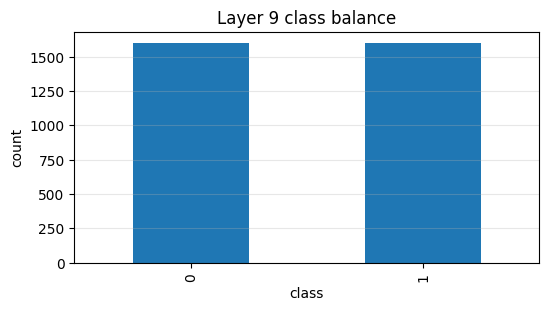

In [ ]:
sheet_9 = clean_table(raw_sheets["9"])
X9, y9 = standard_xy(sheet_9, header=True)

display(pd.concat([X9, y9.rename("y")], axis=1).head())
show_class_balance(y9, "Layer 9 class balance")

### Depth Scan

We scan depths `1` to `8`. The key signal is whether validation jumps only after all five features can be used.

In [ ]:
scores_9 = depth_scan(X9, y9, depths=range(1, 9))
show_scores(scores_9)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.517,0.524,0.011
1,2,2,0.519,0.501,0.006
2,3,3,0.529,0.506,0.016
3,4,4,0.539,0.500,0.007
4,5,5,0.750,0.747,0.009
5,6,5,0.750,0.747,0.009
6,7,5,0.750,0.747,0.009
7,8,5,0.750,0.747,0.009


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

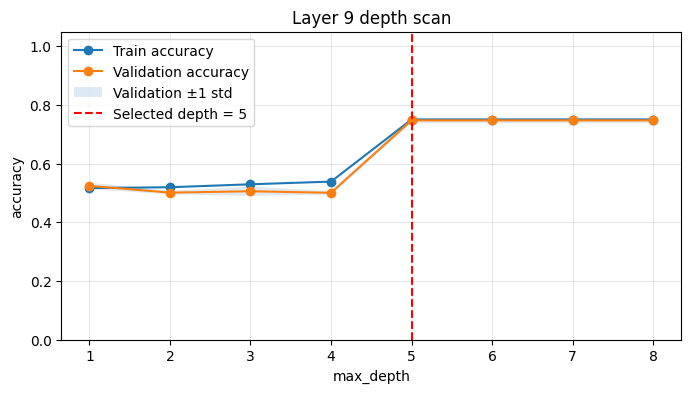

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
4,5,5,0.750,0.747,0.009


In [ ]:
d_9 = 5
plot_depth_scan(scores_9, d_9, "Layer 9 depth scan")
selected_depth_row(scores_9, d_9)

### Conclusion

Depth `5` is selected because validation jumps at this depth, indicating that all five features are needed.

Selected depth:

$$
d_9 = 5
$$

## 3.10 Layer 10

### Data clean-up

Sheet `10` contains `500` rows, `8` numeric features and `8` classes. The value `-9999` is a missing-value sentinel and is replaced by `NaN`.

Missing values after replacing -9999:


,missing_count
x0,3
x1,4
x2,1
x3,3
x4,1
x5,1
x6,1
x7,6


,x0,x1,x2,x3,x4,x5,x6,x7,y
0,3.503886,2.642464,3.664306,3.833483,2.947920,3.705710,3.676710,3.219453,5
1,2.848887,3.899400,3.621217,3.767420,3.552529,3.916195,3.960846,3.010525,6
2,2.957130,2.284148,3.772626,3.557196,3.047982,3.330190,3.551214,1.450336,0
3,3.694401,3.341512,3.619063,3.722999,2.853098,3.431152,3.985813,2.954474,3
4,3.535374,3.980783,3.698736,3.836108,3.237870,3.669669,3.940042,1.930609,5


,count
y,
0,66
1,62
2,62
3,62
4,62
5,62
6,62
7,62


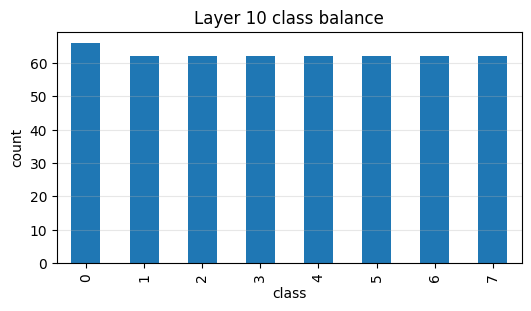

In [ ]:
sheet_10 = clean_table(raw_sheets["10"])
X10, y10 = standard_xy(sheet_10, feature_names=[f"x{i}" for i in range(8)])
X10 = X10.replace(-9999, np.nan)

print("Missing values after replacing -9999:")
display(X10.isna().sum().to_frame("missing_count"))
display(pd.concat([X10, y10.rename("y")], axis=1).head())
show_class_balance(y10, "Layer 10 class balance")

### Depth Scan

We scan depths `1` to `12` after missing-value treatment. The selected depth should peak or stabilize before validation drops.

In [ ]:
scores_10 = depth_scan(X10, y10, depths=range(1, 13))
show_scores(scores_10)

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
0,1,1,0.243,0.221,0.020
1,2,2,0.357,0.324,0.023
2,3,3,0.467,0.413,0.013
3,4,4,0.583,0.463,0.032
4,5,5,0.696,0.549,0.030
5,6,6,0.808,0.569,0.027
6,7,7,0.907,0.624,0.041
7,8,8,0.953,0.619,0.042
8,9,9,0.980,0.619,0.045
9,10,10,0.994,0.601,0.043


### Validation

The plot below compares training and validation accuracy. The red dashed line marks the selected depth. The table below the plot shows the metrics for that selected depth.

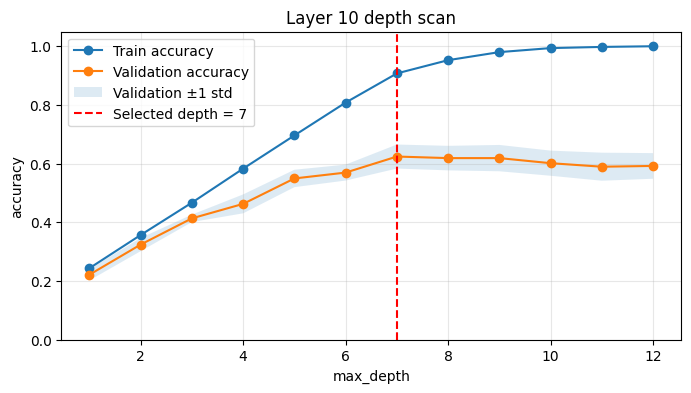

,max_depth,actual_depth_max,train_mean,validation_mean,validation_std
6,7,7,0.907,0.624,0.041


In [ ]:
d_10 = 7
plot_depth_scan(scores_10, d_10, "Layer 10 depth scan")
selected_depth_row(scores_10, d_10)

### Conclusion

Depth `7` is selected because validation peaks/stabilizes there. From depth `8` onward, the tree mostly becomes more complex without better validation performance.

Selected depth:

$$
d_10 = 7
$$

## 3.11 Reconstruct the Digits

The selected depths are interpreted as the ten puzzle digits.

In [ ]:
depths = [d_1, d_2, d_3, d_4, d_5, d_6, d_7, d_8, d_9, d_10]
digits = "".join(str(depth) for depth in depths)

print("Depths:", depths)
print("Digits:", digits)

Depths: [1, 3, 2, 4, 7, 1, 7, 9, 5, 7]
Digits: 1324717957


## 3.12 Navigate the Master Tree

The assignment instructs us to use the 10 collected keys (the optimal depths) to navigate the **Master Tree**:

> At every junction, ignore the doubt and make the decision that is constantly positive.

The Master Tree contains exactly 10 decision junctions (blue rectangles). We must evaluate each junction $k$ using our corresponding key $d_k$.

Let's analyze every decision sequentially:

1. **Junction 1 (`Stump?`)**: Key $d_1 = 1$. A tree of depth 1 is indeed a stump. Result: **Positive (True)**.
2. **Junction 2 (`Odd depth?`)**: Key $d_2 = 3$. $3$ is an odd number. Result: **Positive (True)**.
3. **Junction 3 (`Even depth?`)**: Key $d_3 = 2$. $2$ is an even number. Result: **Positive (True)**.
4. **Junction 4 (`Depth >= 3?`)**: Key $d_4 = 4$. $4 \geq 3$. Result: **Positive (True)**.
5. **Junction 5 (`Depth < 8?`)**: Key $d_5 = 7$. $7 < 8$. Result: **Positive (True)**.
6. **Junction 6 (`Stump?`)**: Key $d_6 = 1$. Depth 1 is a stump. Result: **Positive (True)**.
7. **Junction 7 (`Depth > 5?`)**: Key $d_7 = 7$. $7 > 5$. Result: **Positive (True)**.
8. **Junction 8 (`Depth >= 7?`)**: Key $d_8 = 9$. $9 \geq 7$. Result: **Positive (True)**.
9. **Junction 9 (`Odd depth?`)**: Key $d_9 = 5$. $5$ is an odd number. Result: **Positive (True)**.
10. **Junction 10 (`Depth == 7?`)**: Key $d_{10} = 7$. $7 = 7$. Result: **Positive (True)**.

### Why this leads to the final answer:

Every single key yields a **Positive (True)** decision.

The instruction says to "make the decision that is constantly positive". This means we must take the "True" branch at every junction. Visually, taking the positive branch 10 times in a row forces us to follow the main spine of the tree all the way down. Any "Negative" (False) decision would have led to an early dead end at a wrong constant (such as $\pi$, $e$, $\sigma$, etc.).

By traversing all 10 junctions via the positive path, we arrive exactly at the final leaf at the bottom right:

$$
s_d(\rho)
$$

This perfectly closes the loop: our extracted depths evaluate to `True` at every junction, routing us directly to the constant $\rho$, which is the plastic constant.

In [ ]:
master_tree_conditions = [
    ("Stump?", lambda d: d == 1),
    ("Odd depth?", lambda d: d % 2 != 0),
    ("Even depth?", lambda d: d % 2 == 0),
    ("Depth >= 3?", lambda d: d >= 3),
    ("Depth < 8?", lambda d: d < 8),
    ("Stump?", lambda d: d == 1),
    ("Depth > 5?", lambda d: d > 5),
    ("Depth >= 7?", lambda d: d >= 7),
    ("Odd depth?", lambda d: d % 2 != 0),
    ("Depth == 7?", lambda d: d == 7)
]

all_positive = True
for i, (depth, (condition_name, condition_fn)) in enumerate(zip(depths, master_tree_conditions), 1):
    result = condition_fn(depth)
    print(f"Junction {i:2d} | Key = {depth} | Condition: {condition_name:<15} -> {result}")
    if not result:
        all_positive = False

print("\nConstantly positive?", all_positive)

Junction  1 | Key = 1 | Condition: Stump?          -> True
Junction  2 | Key = 3 | Condition: Odd depth?      -> True
Junction  3 | Key = 2 | Condition: Even depth?     -> True
Junction  4 | Key = 4 | Condition: Depth >= 3?     -> True
Junction  5 | Key = 7 | Condition: Depth < 8?      -> True
Junction  6 | Key = 1 | Condition: Stump?          -> True
Junction  7 | Key = 7 | Condition: Depth > 5?      -> True
Junction  8 | Key = 9 | Condition: Depth >= 7?     -> True
Junction  9 | Key = 5 | Condition: Odd depth?      -> True
Junction 10 | Key = 7 | Condition: Depth == 7?     -> True

Constantly positive? True


# 4. Conclusion

Having successfully navigated the Master Tree, we arrive at the hidden constant $\rho$. The digit sequence is:

$$
1324717957
$$

This matches the first ten digits of the plastic ratio (symbolised by $\rho$) without the decimal point:

$$
\rho \approx 1.324717957\ldots
$$

The plastic ratio is the positive real root of:

$$
x^3 - x - 1 = 0
$$

Applying the puzzle formula gives:

$$
s_{10}(\rho) = 1 + 3 + 2 + 4 + 7 + 1 + 7 + 9 + 5 + 7 = 46
$$

In [ ]:
answer = sum(int(digit) for digit in digits)
print("Final answer:", answer)

Final answer: 46


Final answer:

$$
\boxed{46}
$$

This matches the final clue: “the blueprint that makes us human”. Humans typically have **46 chromosomes**.